# Understanding Seaborn: A Statistical Visualization Library

## Why Choose Seaborn Over Matplotlib?

Seaborn provides several advantages over Matplotlib:

- **Simpler API**: Write less code to create complex statistical visualizations
- **Beautiful Default Aesthetics**: Professional-looking plots out of the box with better color palettes and styling
- **Better Integration with Pandas**: Works seamlessly with DataFrames, making data manipulation and visualization easier
- **Statistical Estimation**: Automatically computes and visualizes statistical relationships (regression, confidence intervals)
- **Multi-plot Grids**: Easy creation of faceted plots using figure-level functions
- **Built-in Themes**: Multiple pre-configured color schemes and styles

# Seaborn Plot Types Roadmap

## Classification by Function Level

### Figure-Level Functions (High-level Interface)
These functions create their own matplotlib figure and can work with multiple subplots automatically:
- `relplot()`, `displot()`, `catplot()`, `lmplot()`, `jointplot()`, `pairplot()`

### Axis-Level Functions (Low-level Interface)
These functions work with existing matplotlib axes and need to be drawn on a specific axis:
- `scatterplot()`, `lineplot()`, `histplot()`, `kdeplot()`, `heatmap()`, `barplot()`, etc.

## Classification by Purpose

1. **Relational Plots**: Show relationships between continuous variables (scatterplot, lineplot)
2. **Distribution Plots**: Analyze univariate or bivariate distributions (histplot, kdeplot, rugplot)
3. **Categorical Plots**: Compare distributions across categorical groups (barplot, boxplot, violinplot, stripplot)
4. **Regression Plots**: Visualize relationships with statistical regression fits
5. **Matrix Plots**: Display matrices or DataFrames as heatmaps (heatmap, clustermap)
6. **Multi-plot Grids**: Combine multiple plots systematically (FacetGrid, PairGrid)

For complete API reference: https://seaborn.pydata.org/api.html

# 1. Relational Plots

## Purpose
Relational plots are used to visualize the statistical relationship between two or more continuous numerical variables. They answer questions like:
- How does Variable A change with Variable B?
- Is there a correlation between two variables?
- How do multiple variables interact?

## Plot Types Under Relational Category

### Scatter Plot
- Shows individual data points as markers on a 2D plane
- Useful for identifying clusters, outliers, and correlation patterns
- Can encode additional dimensions using color (hue), marker style, and size

### Line Plot
- Connects data points with lines, useful for time series and sequences
- Shows trends and patterns over an ordered axis
- Can display multiple lines for different categories using hue parameter

In [1]:
# Import Required Libraries
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set style for all plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load E-commerce Sales Dataset
# This dataset contains information about online store purchases
sales_data = sns.load_dataset('tips')  # Using tips as base, but renaming columns for clarity
sales_data = sales_data.rename(columns={
    'total_bill': 'purchase_amount',
    'tip': 'customer_satisfaction',
    'sex': 'customer_gender',
    'time': 'order_time'
})

print("Dataset shape:", sales_data.shape)
print("\nFirst few records:")
display(sales_data.head())
print("\nDataset Info:")
print(sales_data.info())

Dataset shape: (244, 7)

First few records:


,purchase_amount,customer_satisfaction,customer_gender,smoker,day,order_time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   purchase_amount        244 non-null    float64 
 1   customer_satisfaction  244 non-null    float64 
 2   customer_gender        244 non-null    category
 3   smoker                 244 non-null    category
 4   day                    244 non-null    category
 5   order_time             244 non-null    category
 6   size                   244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


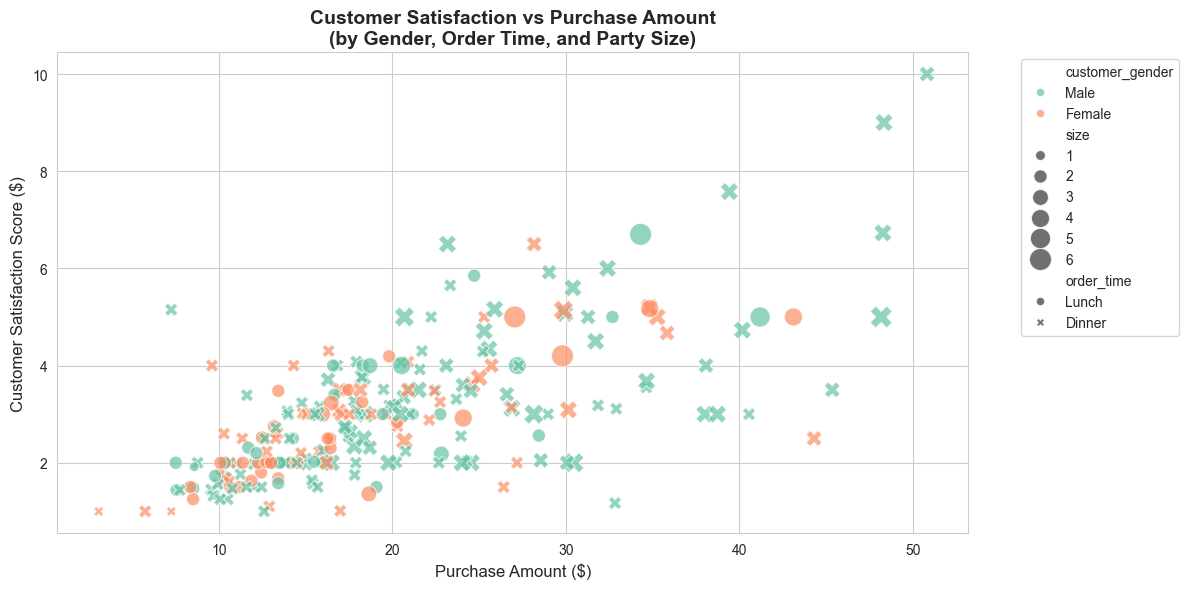

Interpretation:
- Points scattered upward suggest higher satisfaction with bigger purchases
- Color grouping shows if gender affects satisfaction patterns
- Point size indicates party size impact on spending


In [3]:
# Scatter Plot with Multiple Dimensions (Axes-Level Function)
# 
# This scatter plot shows:
# - X-axis: Purchase amount (numerical)
# - Y-axis: Customer satisfaction score (numerical)
# - Color (hue): Customer gender (categorical - differentiate by color)
# - Size: Party size (numerical - larger points = larger groups)
# - Marker style: Order time (categorical - lunch vs dinner)

fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=sales_data, 
    x='purchase_amount', 
    y='customer_satisfaction',
    hue='customer_gender',           # Color code by gender
    style='order_time',              # Different marker styles for lunch/dinner
    size='size',                     # Size represents party size
    palette='Set2',                  # Color palette
    sizes=(50, 250),                 # Size range
    alpha=0.7,                       # Transparency
    ax=ax
)

plt.title('Customer Satisfaction vs Purchase Amount\n(by Gender, Order Time, and Party Size)', fontsize=14, fontweight='bold')
plt.xlabel('Purchase Amount ($)', fontsize=12)
plt.ylabel('Customer Satisfaction Score ($)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Points scattered upward suggest higher satisfaction with bigger purchases")
print("- Color grouping shows if gender affects satisfaction patterns")
print("- Point size indicates party size impact on spending")

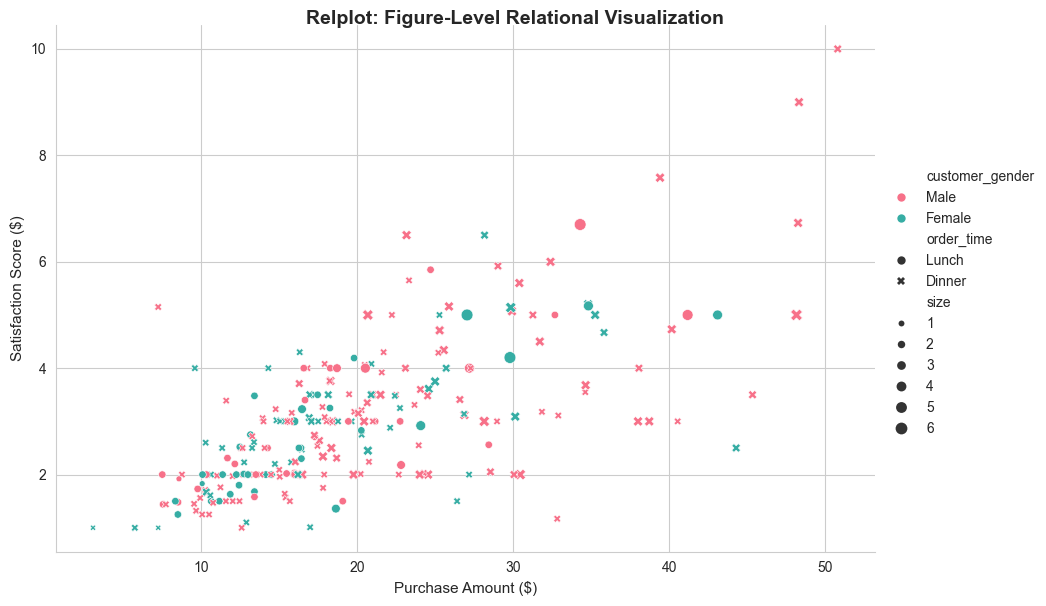


Key Points about relplot():
✓ Figure-level function (creates figure automatically)
✓ Supports faceting (col, row parameters)
✓ Better control over figure aesthetics
✓ Returns a FacetGrid object


In [4]:
# Relational Figure-Level Function
# 
# Key difference: relplot() creates a figure-level plot
# - It creates its own figure instead of using existing axes
# - Results in a square aspect ratio (better for printing/presentations)
# - Better for creating multi-plot grids

g = sns.relplot(
    data=sales_data, 
    x='purchase_amount', 
    y='customer_satisfaction',
    kind='scatter',
    hue='customer_gender',
    style='order_time',
    size='size',
    palette='husl',
    height=6,
    aspect=1.5
)

g.fig.suptitle('Relplot: Figure-Level Relational Visualization', fontsize=14, fontweight='bold', y=1.00)
g.set_axis_labels('Purchase Amount ($)', 'Satisfaction Score ($)', fontsize=11)
plt.show()

print("\nKey Points about relplot():")
print("✓ Figure-level function (creates figure automatically)")
print("✓ Supports faceting (col, row parameters)")
print("✓ Better control over figure aesthetics")
print("✓ Returns a FacetGrid object")

## Semantic Mapping in Scatter Plots

Seaborn allows you to map data dimensions to visual properties:
- **hue**: Maps categorical variables to colors
- **style**: Maps categorical variables to marker styles (circle, square, triangle, etc.)
- **size**: Maps numerical variables to marker sizes
- **palette**: Specifies color scheme (Set1, Set2, husl, viridis, etc.)
- **alpha**: Controls transparency (0=invisible, 1=opaque)

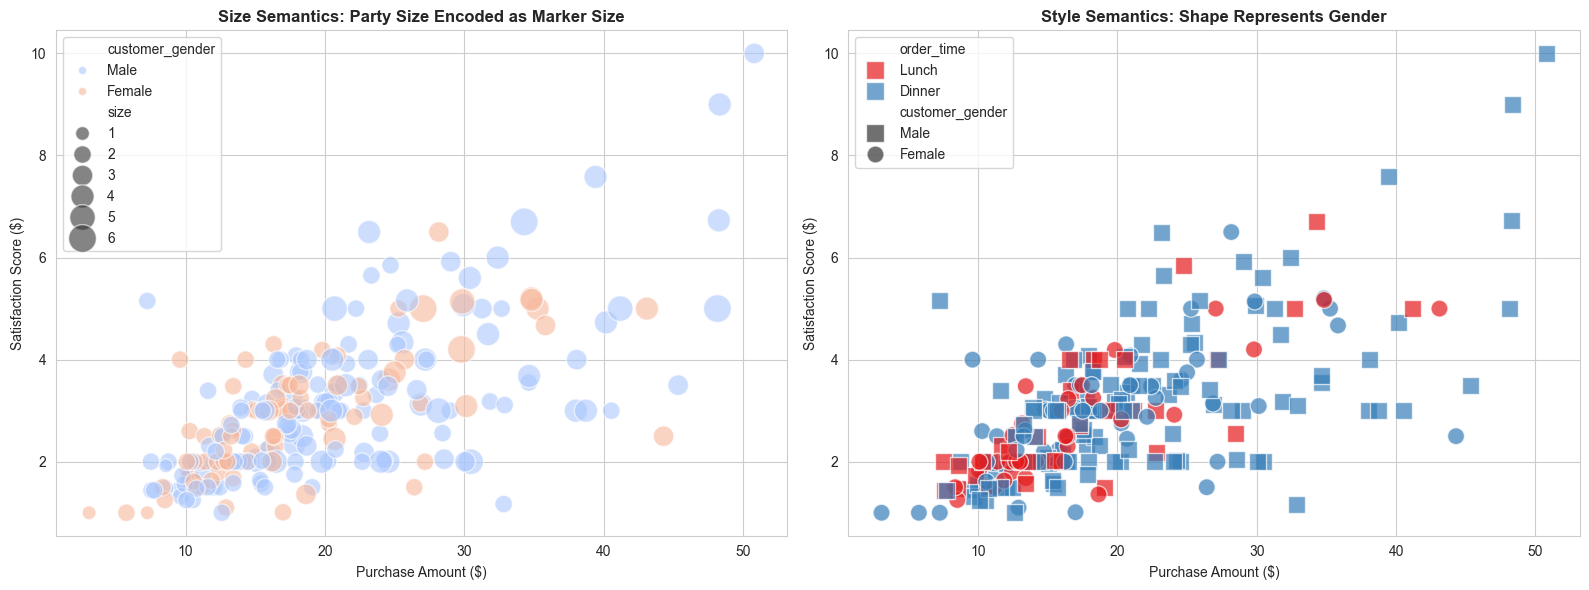

In [5]:
# Example: Using Size and Hue Mapping
# This demonstrates how to encode 4 dimensions in a single scatter plot

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Size mapping
sns.scatterplot(
    data=sales_data,
    x='purchase_amount',
    y='customer_satisfaction',
    size='size',
    sizes=(100, 400),
    hue='customer_gender',
    palette='coolwarm',
    ax=axes[0],
    alpha=0.6
)
axes[0].set_title('Size Semantics: Party Size Encoded as Marker Size', fontweight='bold')
axes[0].set_xlabel('Purchase Amount ($)')
axes[0].set_ylabel('Satisfaction Score ($)')

# Right plot: Style mapping with hue
sns.scatterplot(
    data=sales_data,
    x='purchase_amount',
    y='customer_satisfaction',
    hue='order_time',
    style='customer_gender',
    markers={'Female': 'o', 'Male': 's'},  # Circle for Female, Square for Male
    palette='Set1',
    s=150,
    ax=axes[1],
    alpha=0.7
)
axes[1].set_title('Style Semantics: Shape Represents Gender', fontweight='bold')
axes[1].set_xlabel('Purchase Amount ($)')
axes[1].set_ylabel('Satisfaction Score ($)')

plt.tight_layout()
plt.show()

In [6]:
# Prepare Time Series Data: Flights Dataset
# This dataset shows airline passenger data from 1949-1960

flights_data = sns.load_dataset('flights')

print("Flights Dataset Overview:")
print("Shape:", flights_data.shape)
print("\nColumns:", flights_data.columns.tolist())
print("\nFirst few records:")
display(flights_data.head(10))
print("\nDataset Summary Statistics:")
display(flights_data.describe())

Flights Dataset Overview:
Shape: (144, 3)

Columns: ['year', 'month', 'passengers']

First few records:


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
5,1949,Jun,135
6,1949,Jul,148
7,1949,Aug,148
8,1949,Sep,136
9,1949,Oct,119



Dataset Summary Statistics:


,year,passengers
count,144.000000,144.000000
mean,1954.500000,280.298611
std,3.464102,119.966317
min,1949.000000,104.000000
25%,1951.750000,180.000000
50%,1954.500000,265.500000
75%,1957.250000,360.500000
max,1960.000000,622.000000


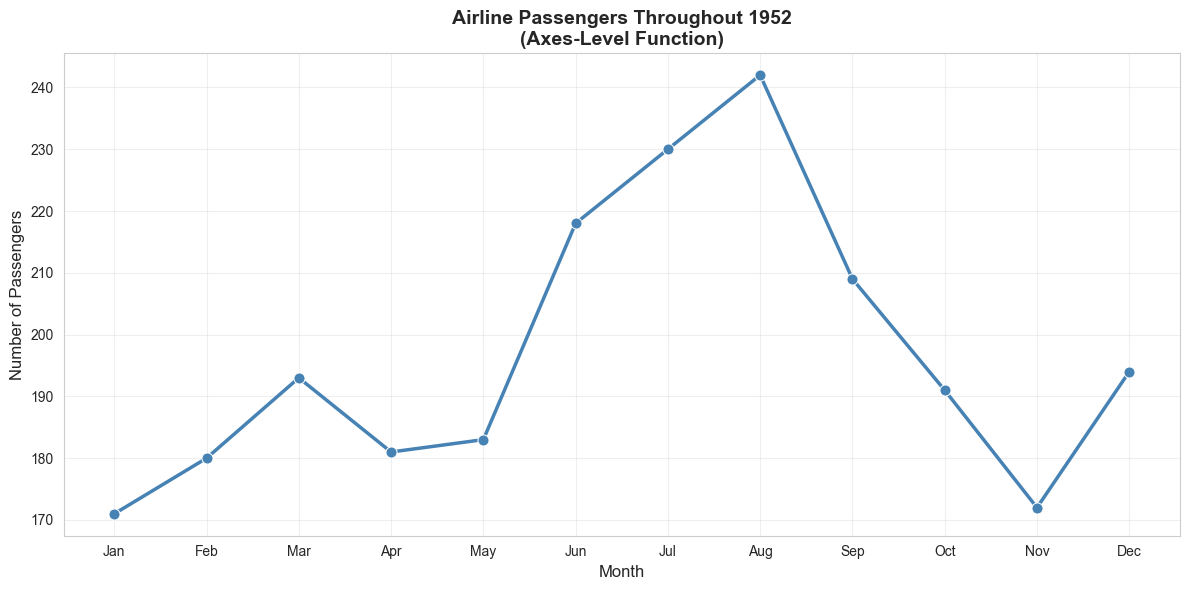

Key Observations:
- Shows seasonal patterns in passenger traffic
- Axes-level function: Works with existing matplotlib axes
- Useful for single line plots or adding to existing figures


In [7]:
# Line Plot: Axes-Level Function for Individual Series
# 
# Select data for a single airline to show trend over time

singapore_airline = flights_data[flights_data['year'] == 1952]

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=singapore_airline,
    x='month',
    y='passengers',
    marker='o',
    linewidth=2.5,
    markersize=8,
    color='steelblue',
    ax=ax
)

ax.set_title('Airline Passengers Throughout 1952\n(Axes-Level Function)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Passengers', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Observations:")
print("- Shows seasonal patterns in passenger traffic")
print("- Axes-level function: Works with existing matplotlib axes")
print("- Useful for single line plots or adding to existing figures")

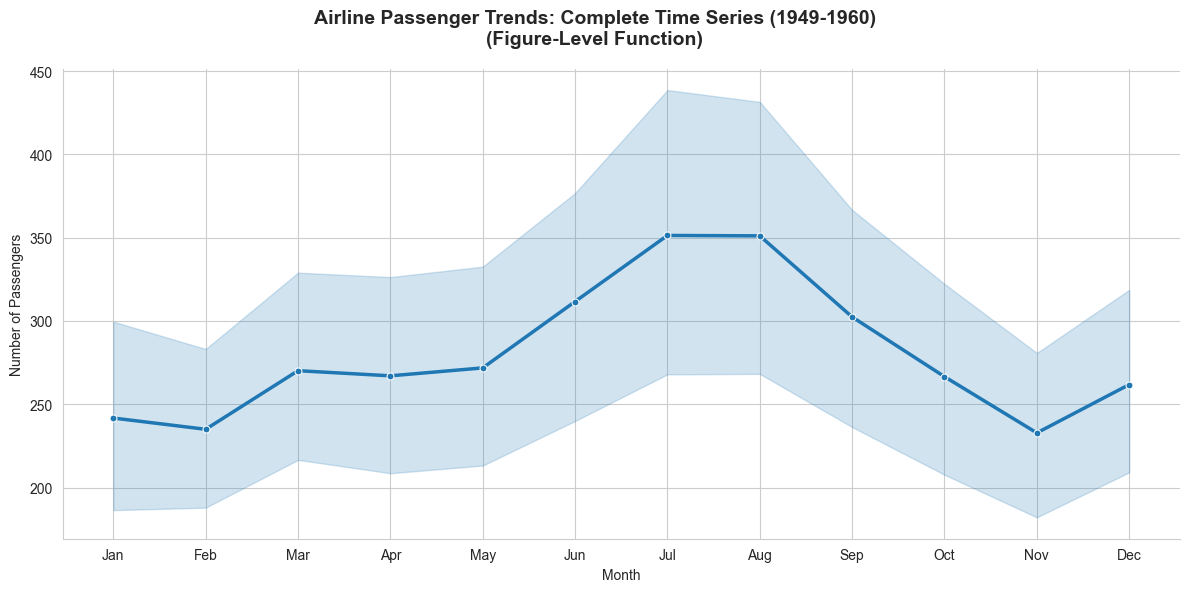

Observations:
✓ Shows long-term trend with seasonal fluctuations
✓ Peaks typically occur in summer (vacation season)
✓ Troughs in winter (fewer travelers)
✓ Overall upward trend from 1949-1960


In [8]:
# Figure-Level Line Plot: Full Time Series
# 
# Using relplot with 'line' kind to show complete trend

g = sns.relplot(
    data=flights_data,
    x='month',
    y='passengers',
    kind='line',
    height=6,
    aspect=2,
    linewidth=2.5,
    marker='o',
    markersize=5
)

g.fig.suptitle('Airline Passenger Trends: Complete Time Series (1949-1960)\n(Figure-Level Function)', 
               fontsize=14, fontweight='bold', y=0.98)
g.set_axis_labels('Month', 'Number of Passengers')

plt.tight_layout()
plt.show()

print("Observations:")
print("✓ Shows long-term trend with seasonal fluctuations")
print("✓ Peaks typically occur in summer (vacation season)") 
print("✓ Troughs in winter (fewer travelers)")
print("✓ Overall upward trend from 1949-1960")

In [9]:
# Compare Multiple Series Using Hue and Style
# 
# Create a dataset showing passengers by specific months across different years

flights_subset = flights_data[flights_data['month'].isin(['Jan', 'Apr', 'Jul', 'Oct'])].copy()

print("Subset of Flights Data (Sample Months):")
print(f"Shape: {flights_subset.shape}")
display(flights_subset.head(15))

Subset of Flights Data (Sample Months):
Shape: (48, 3)


,year,month,passengers
0,1949,Jan,112
3,1949,Apr,129
6,1949,Jul,148
9,1949,Oct,119
12,1950,Jan,115
15,1950,Apr,135
18,1950,Jul,170
21,1950,Oct,133
24,1951,Jan,145
27,1951,Apr,163


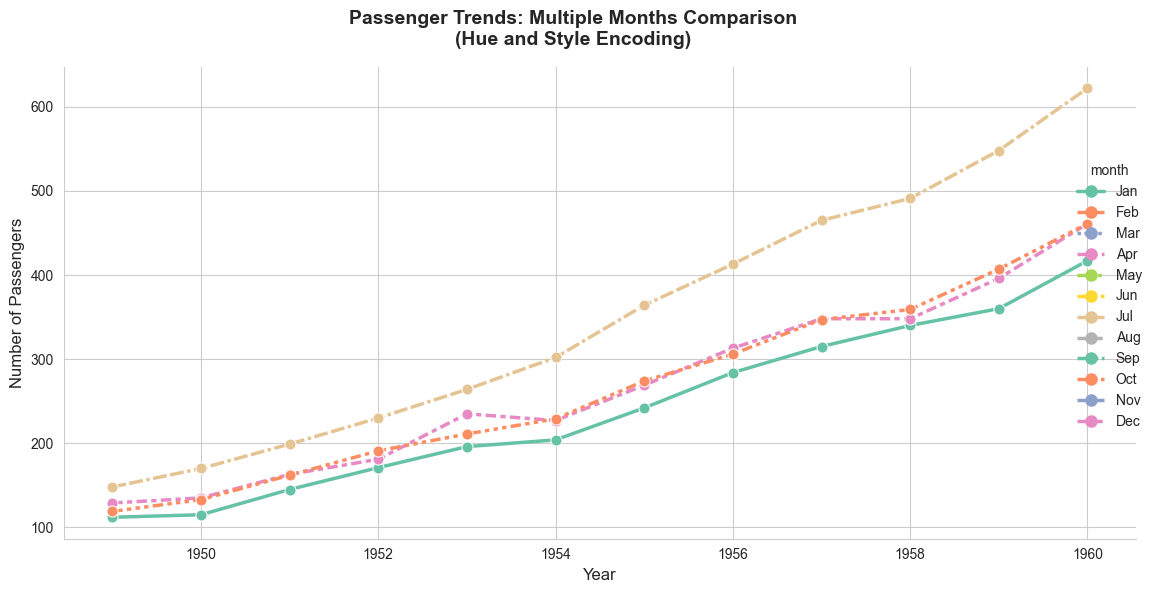

Analysis:
- July (peak season) consistently shows highest passenger numbers
- Pattern repeats across years showing strong seasonality
- January shows consistent but lower passenger traffic


In [10]:
# Multi-Line Plot with Multiple Dimensions
# 
# Show how passenger numbers change across years for different months

g = sns.relplot(
    data=flights_subset,
    x='year',
    y='passengers',
    kind='line',
    hue='month',              # Different colors for different months
    style='month',            # Different marker styles
    height=6,
    aspect=1.8,
    palette='Set2',
    linewidth=2.5,
    marker='o',
    markersize=8
)

g.fig.suptitle('Passenger Trends: Multiple Months Comparison\n(Hue and Style Encoding)', 
               fontsize=14, fontweight='bold', y=0.98)
g.set_axis_labels('Year', 'Number of Passengers', fontsize=12)

plt.tight_layout()
plt.show()

print("Analysis:")
print("- July (peak season) consistently shows highest passenger numbers")
print("- Pattern repeats across years showing strong seasonality")
print("- January shows consistent but lower passenger traffic")

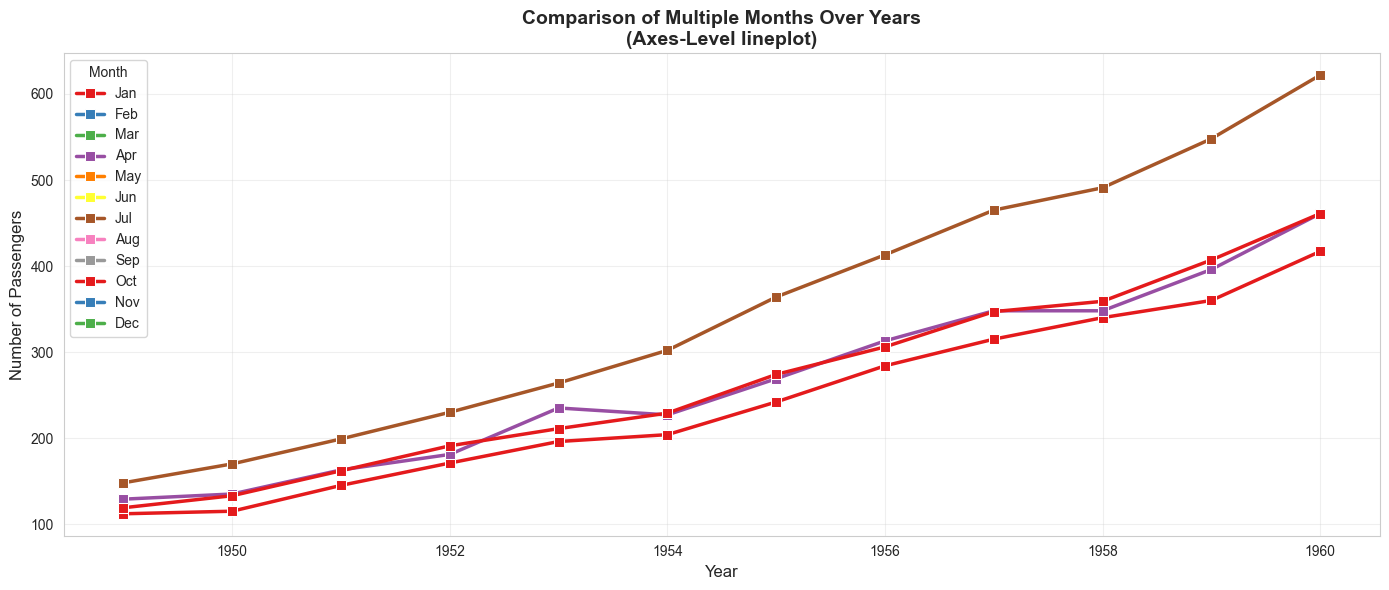

In [11]:
# Axes-Level Line Plot with Multiple Series
# 
# Using lineplot directly on multiple categories

fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=flights_subset,
    x='year',
    y='passengers',
    hue='month',
    palette='Set1',
    linewidth=2.5,
    marker='s',
    markersize=7,
    ax=ax
)

ax.set_title('Comparison of Multiple Months Over Years\n(Axes-Level lineplot)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Passengers', fontsize=12)
ax.legend(title='Month', frameon=True, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

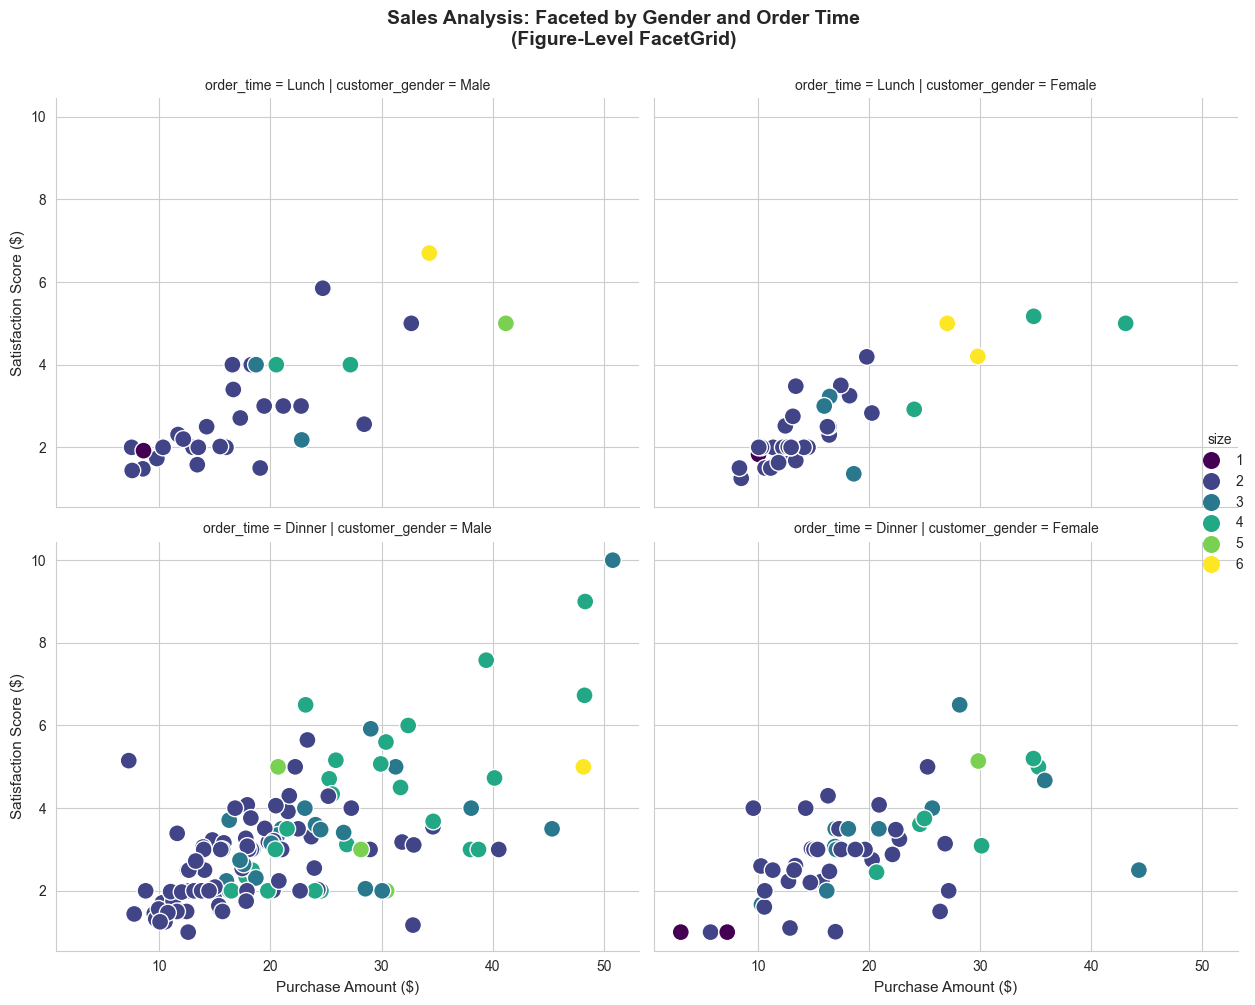

Benefits of Faceting:
✓ Compare patterns across different subgroups
✓ Reduce visual clutter by separating categories
✓ Easy identification of group-specific trends


In [12]:
# Facet Plot: Creating Subplots by Category
# 
# FacetGrid is powerful for comparing subsets of data side-by-side
# Shows scatter plots of sales data, separated by customer gender and order time

g = sns.relplot(
    data=sales_data,
    x='purchase_amount',
    y='customer_satisfaction',
    kind='scatter',
    height=5,
    aspect=1.2,
    col='customer_gender',           # Separate columns by gender
    row='order_time',                # Separate rows by order time (lunch/dinner)
    hue='size',                      # Color by party size
    palette='viridis',
    s=150
)

g.fig.suptitle('Sales Analysis: Faceted by Gender and Order Time\n(Figure-Level FacetGrid)', 
               fontsize=14, fontweight='bold', y=1.00)
g.set_axis_labels('Purchase Amount ($)', 'Satisfaction Score ($)', fontsize=11)

plt.tight_layout()
plt.show()

print("Benefits of Faceting:")
print("✓ Compare patterns across different subgroups")
print("✓ Reduce visual clutter by separating categories")
print("✓ Easy identification of group-specific trends")

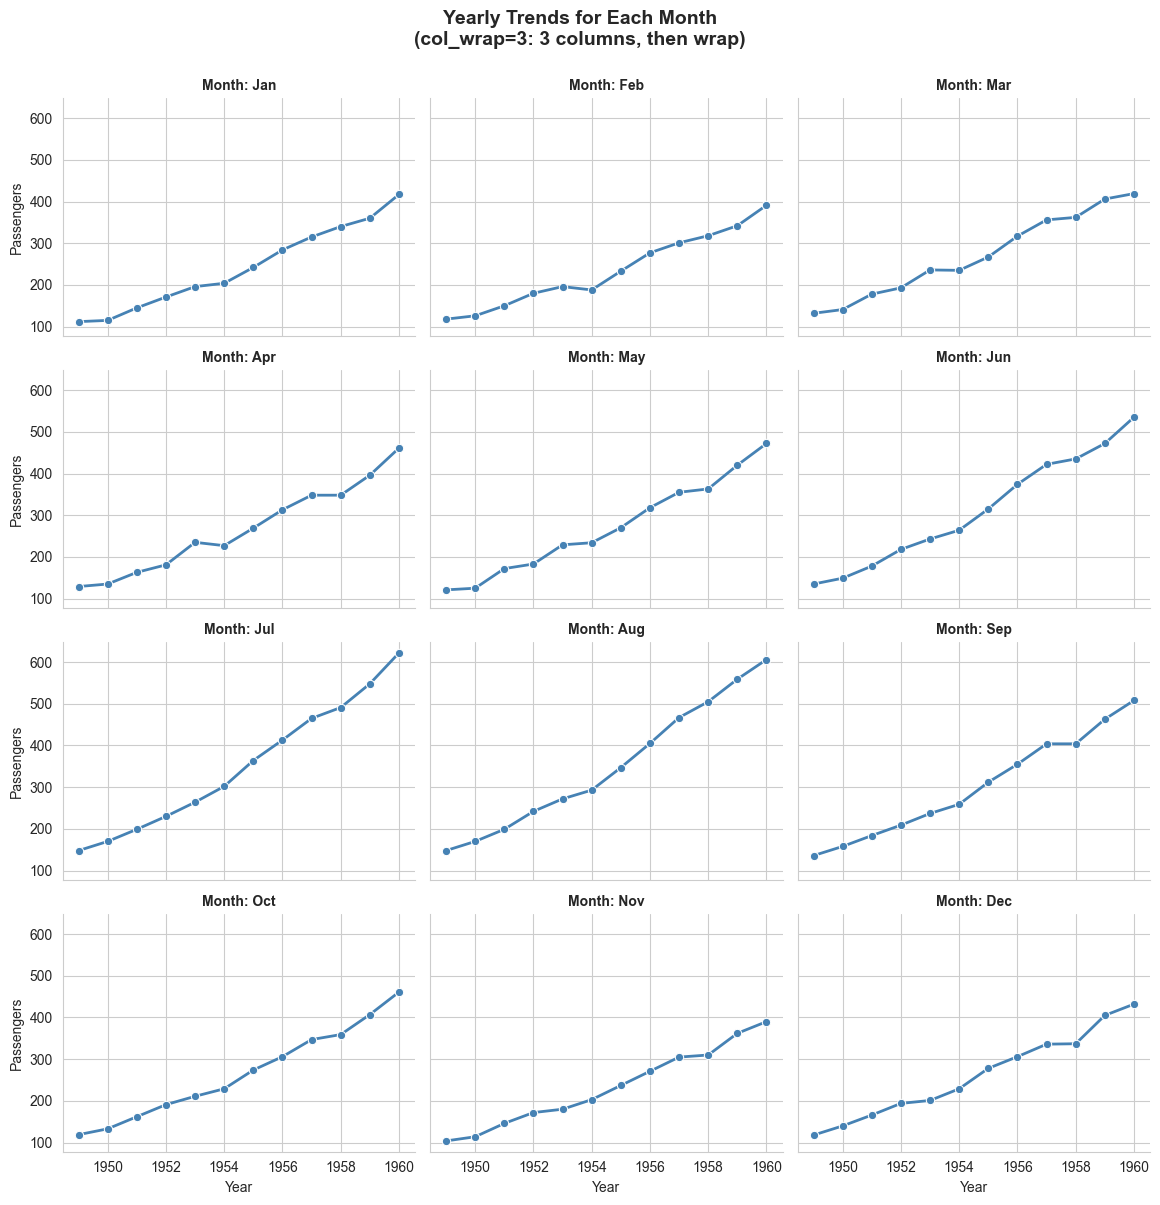

col_wrap Parameter:
- Used when you want automatic wrapping instead of a full grid
- Reduces figure height by arranging subplots horizontally
- Perfect for comparing many categories (12 months in this case)


In [13]:
# Column Wrapping: Create Grid Layout with Limited Columns
# 
# Use col_wrap to arrange multiple facets without rows
# This is useful when you have many categories

g = sns.relplot(
    data=flights_data,
    x='year',
    y='passengers',
    kind='line',
    col='month',                     # Separate plot for each month
    col_wrap=3,                      # Only 3 columns per row, then wrap to next row
    height=3,
    aspect=1.3,
    linewidth=2,
    marker='o',
    color='steelblue'
)

g.fig.suptitle('Yearly Trends for Each Month\n(col_wrap=3: 3 columns, then wrap)', 
               fontsize=14, fontweight='bold', y=1.00)
g.set_titles('Month: {col_name}', fontweight='bold')
g.set_axis_labels('Year', 'Passengers')

plt.tight_layout()
plt.show()

print("col_wrap Parameter:")
print("- Used when you want automatic wrapping instead of a full grid")
print("- Reduces figure height by arranging subplots horizontally")
print("- Perfect for comparing many categories (12 months in this case)")

In [14]:
# Important Note: Faceting Only Works with Figure-Level Functions
# 
# Axes-level functions (scatterplot, lineplot) do NOT support col/row parameters
# Only figure-level functions (relplot, displot, etc.) support faceting

print("✓ Figure-Level Functions (Support Faceting):")
print("  - relplot(), displot(), catplot(), lmplot(), jointplot(), pairplot()")
print("\n✗ Axes-Level Functions (Do NOT Support Faceting):")
print("  - scatterplot(), lineplot(), histplot(), kdeplot(), barplot(), etc.")
print("\n→ Use relplot() and displot() when you need col/row faceting")

✓ Figure-Level Functions (Support Faceting):
  - relplot(), displot(), catplot(), lmplot(), jointplot(), pairplot()

✗ Axes-Level Functions (Do NOT Support Faceting):
  - scatterplot(), lineplot(), histplot(), kdeplot(), barplot(), etc.

→ Use relplot() and displot() when you need col/row faceting


# 2. Distribution Plots

## Purpose
Distribution plots are used for **univariate analysis** (analyzing a single variable). They help answer questions like:
- What is the shape of the data distribution?
- Is the data normally distributed?
- Where are the data concentrated?
- Are there outliers or gaps in the data?
- Are there multiple peaks (multimodal)?

## Key Statistics Shown
- **Range**: Minimum and maximum values
- **Central Tendency**: Where data clusters (mean, median, mode)
- **Spread**: How dispersed the data is (variance, standard deviation)
- **Skewness**: Whether data is symmetric or skewed to one side
- **Kurtosis**: How peaked or flat the distribution is

## Plot Types Under Distribution Category
- **histplot**: Discrete bins showing frequency/count
- **kdeplot**: Smooth continuous density curve via Kernel Density Estimation
- **rugplot**: Individual data points shown as ticks on axes

## Function Levels

**Figure-Level Function:**
- `displot()` - Creates its own figure, supports faceting and multi-plot layouts

**Axes-Level Functions:**
- `histplot()` - Histogram with flexible binning
- `kdeplot()` - Kernel Density Estimation plot
- `rugplot()` - Individual data points as ticks

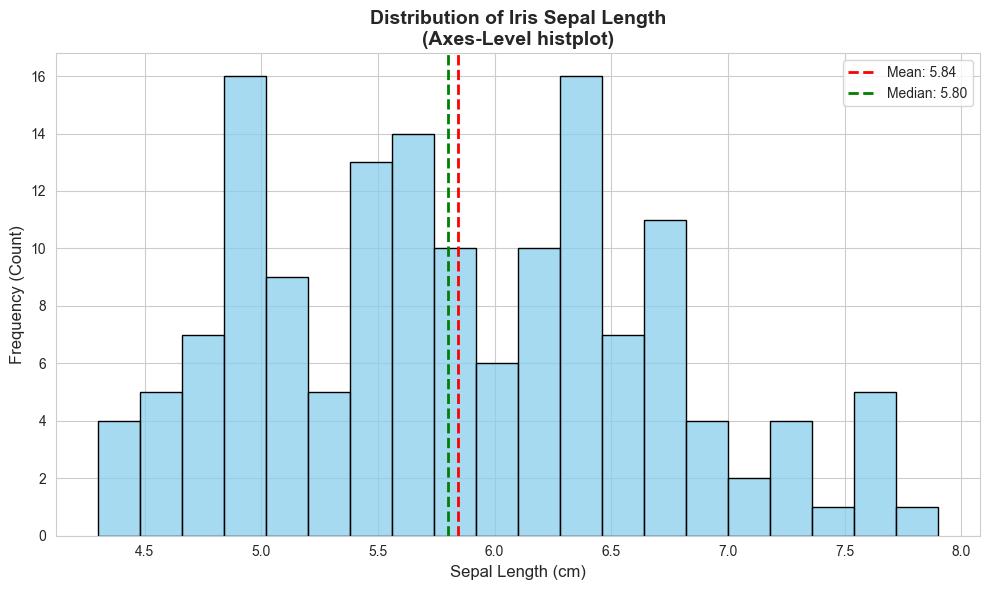

Histogram Interpretation:
- Mean Sepal Length: 5.84 cm
- Median Sepal Length: 5.80 cm
- Range: 4.30 - 7.90 cm
- Distribution shape: Approximately unimodal, slightly right-skewed


In [15]:
# Univariate Histogram: Distribution of a Single Variable
# 
# Axes-level function: histplot()
# Shows frequency distribution of sepal length in iris flowers
from seaborn import load_dataset
iris = load_dataset('iris')

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=iris,
    x='sepal_length',
    bins=20,
    kde=False,
    color='skyblue',
    edgecolor='black',
    ax=ax
)

ax.set_title('Distribution of Iris Sepal Length\n(Axes-Level histplot)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sepal Length (cm)', fontsize=12)
ax.set_ylabel('Frequency (Count)', fontsize=12)
ax.axvline(iris['sepal_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {iris["sepal_length"].mean():.2f}')
ax.axvline(iris['sepal_length'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {iris["sepal_length"].median():.2f}')
ax.legend()

plt.tight_layout()
plt.show()

print("Histogram Interpretation:")
print(f"- Mean Sepal Length: {iris['sepal_length'].mean():.2f} cm")
print(f"- Median Sepal Length: {iris['sepal_length'].median():.2f} cm")
print(f"- Range: {iris['sepal_length'].min():.2f} - {iris['sepal_length'].max():.2f} cm")
print("- Distribution shape: Approximately unimodal, slightly right-skewed")

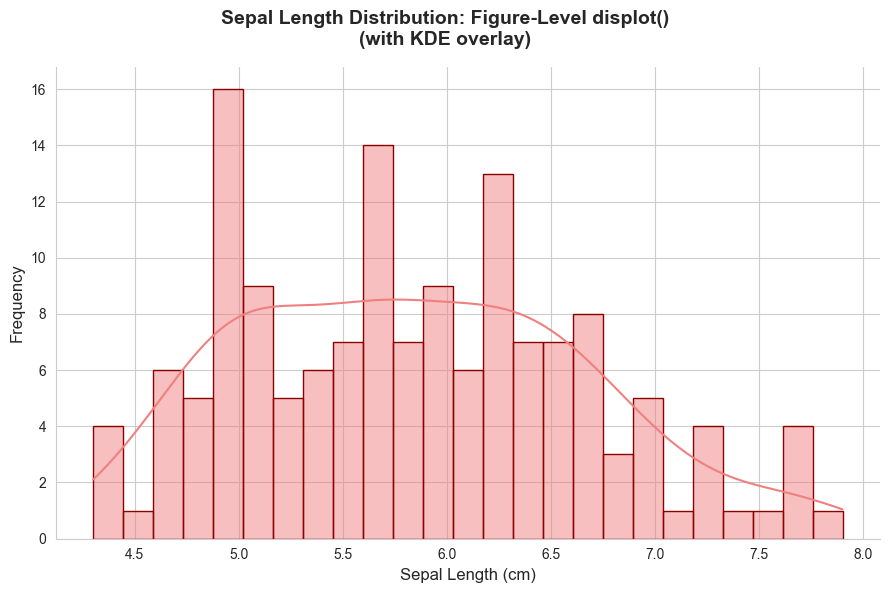

Figure-Level displot():
✓ Automatically creates a clean figure
✓ Beautiful defaults for styling
✓ Supports 'hist', 'kde', 'ecdf' kinds
✓ Returns a FacetGrid object for further customization


In [16]:
# Figure-Level Distribution Plot: displot()
# 
# Creates a figure-level histogram with automatic layout

g = sns.displot(
    data=iris,
    x='sepal_length',
    kind='hist',
    bins=25,
    kde=True,
    height=6,
    aspect=1.5,
    color='lightcoral',
    edgecolor='darkred'
)

g.fig.suptitle('Sepal Length Distribution: Figure-Level displot()\n(with KDE overlay)', 
               fontsize=14, fontweight='bold', y=0.98)
g.set_axis_labels('Sepal Length (cm)', 'Frequency', fontsize=12)

plt.tight_layout()
plt.show()

print("Figure-Level displot():")
print("✓ Automatically creates a clean figure")
print("✓ Beautiful defaults for styling")
print("✓ Supports 'hist', 'kde', 'ecdf' kinds")
print("✓ Returns a FacetGrid object for further customization")

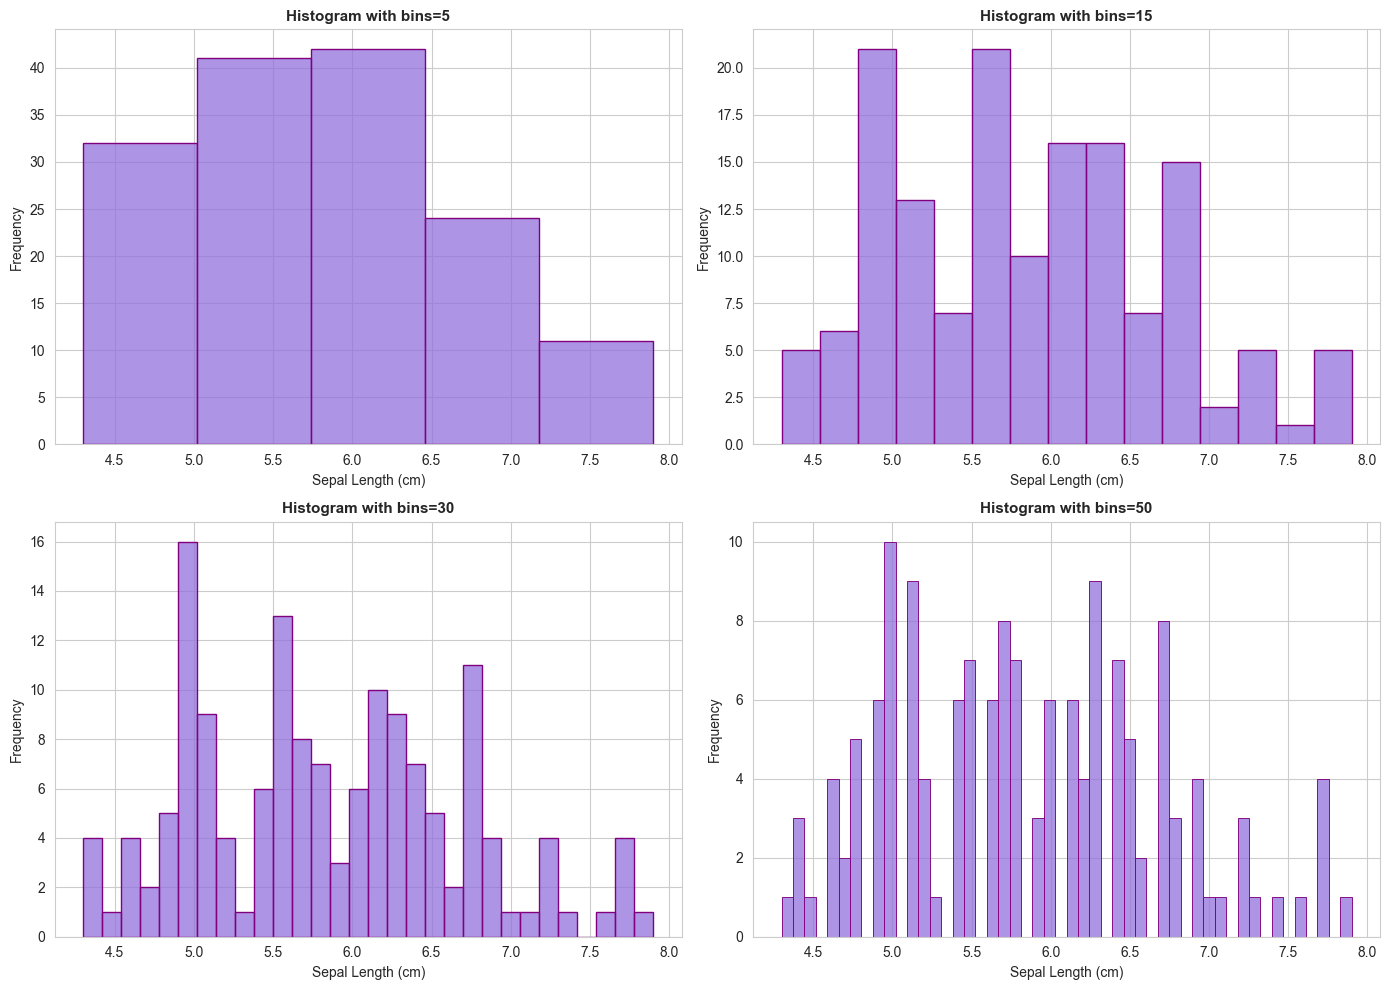

Understanding the Bins Parameter:
- Small bins (5): Too coarse, lose detail
- Medium bins (15): Good balance, shows main pattern
- Large bins (30): More detail, shows fine structure
- Very large bins (50): May show noise and artifacts


In [17]:
# Impact of Bins Parameter on Histogram
# 
# The bins parameter controlsthe trade-off between detail and simplicity

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

bin_counts = [5, 15, 30, 50]

for idx, ax in enumerate(axes.flat):
    sns.histplot(
        data=iris,
        x='sepal_length',
        bins=bin_counts[idx],
        kde=False,
        color='mediumpurple',
        edgecolor='purple',
        ax=ax
    )
    ax.set_title(f'Histogram with bins={bin_counts[idx]}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Sepal Length (cm)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Understanding the Bins Parameter:")
print("- Small bins (5): Too coarse, lose detail")
print("- Medium bins (15): Good balance, shows main pattern")
print("- Large bins (30): More detail, shows fine structure")
print("- Very large bins (50): May show noise and artifacts")

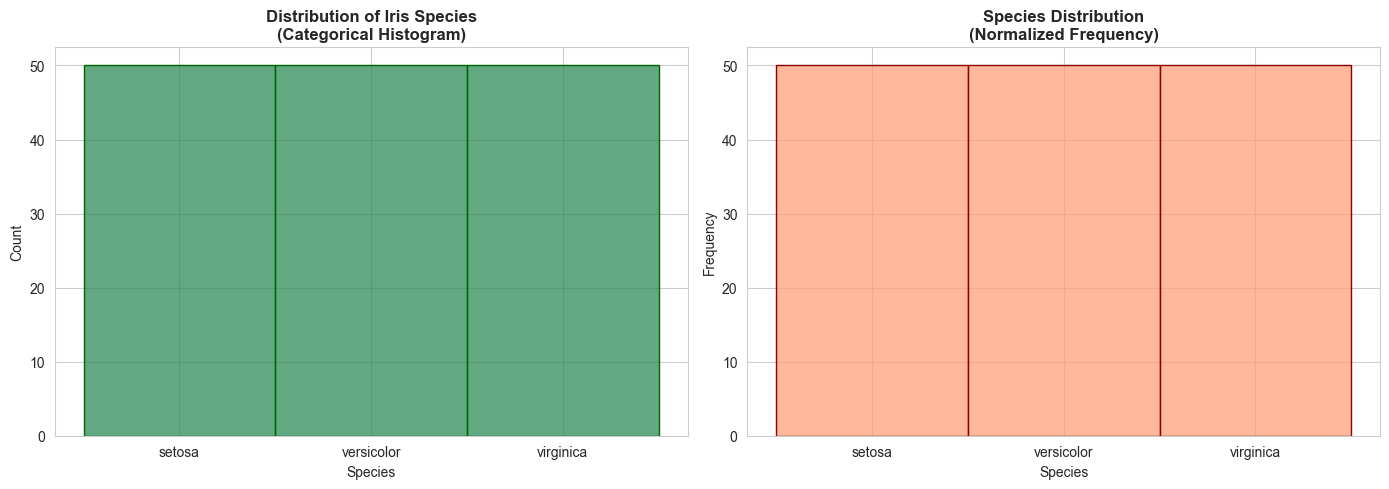

Categorical Variable Distribution:
setosa: 50 samples (33.3%)
versicolor: 50 samples (33.3%)
virginica: 50 samples (33.3%)


In [18]:
# Histogram for Categorical Variables
# 
# For categorical data, histplot automatically uses discrete bins
# This is equivalent to a count plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Categorical histogram
sns.histplot(
    data=iris,
    x='species',
    bins=3,
    kde=False,
    color='seagreen',
    edgecolor='darkgreen',
    stat='count',
    ax=axes[0]
)
axes[0].set_title('Distribution of Iris Species\n(Categorical Histogram)', fontweight='bold')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Count')

# Right: Same data with stat='frequency'
sns.histplot(
    data=iris,
    x='species',
    bins=3,
    kde=False,
    color='lightsalmon',
    edgecolor='darkred',
    stat='frequency',
    ax=axes[1]
)
axes[1].set_title('Species Distribution\n(Normalized Frequency)', fontweight='bold')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Categorical Variable Distribution:")
for species in iris['species'].unique():
    count = len(iris[iris['species'] == species])
    pct = (count / len(iris)) * 100
    print(f"{species}: {count} samples ({pct:.1f}%)")

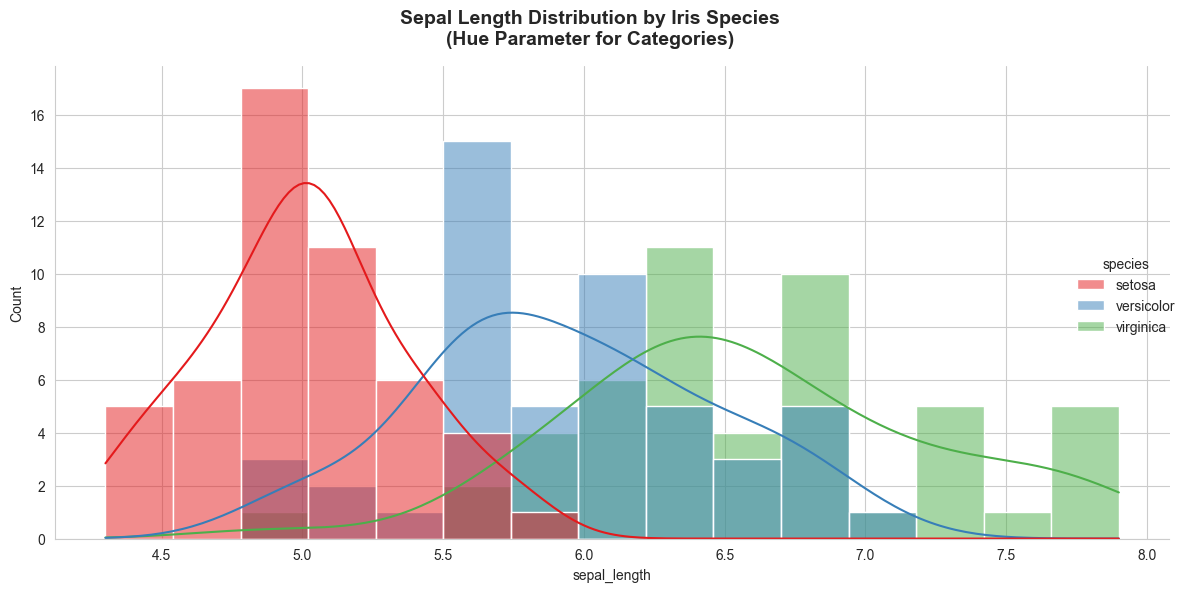

Insights from Hue-Based Distribution:
- Different species have different sepal length ranges
- Setosa: Shorter sepal lengths (4-6 cm)
- Versicolor: Medium sepal lengths (6-7 cm)
- Virginica: Longer sepal lengths (6-8 cm)


In [19]:
# Multivariate Distribution: Using Hue Parameter
# 
# Compare distributions across categories

g = sns.displot(
    data=iris,
    x='sepal_length',
    kind='hist',
    hue='species',
    kde=True,
    bins=15,
    palette='Set1',
    height=6,
    aspect=1.8
)

g.fig.suptitle('Sepal Length Distribution by Iris Species\n(Hue Parameter for Categories)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("Insights from Hue-Based Distribution:")
print("- Different species have different sepal length ranges")
print("- Setosa: Shorter sepal lengths (4-6 cm)")
print("- Versicolor: Medium sepal lengths (6-7 cm)")
print("- Virginica: Longer sepal lengths (6-8 cm)")

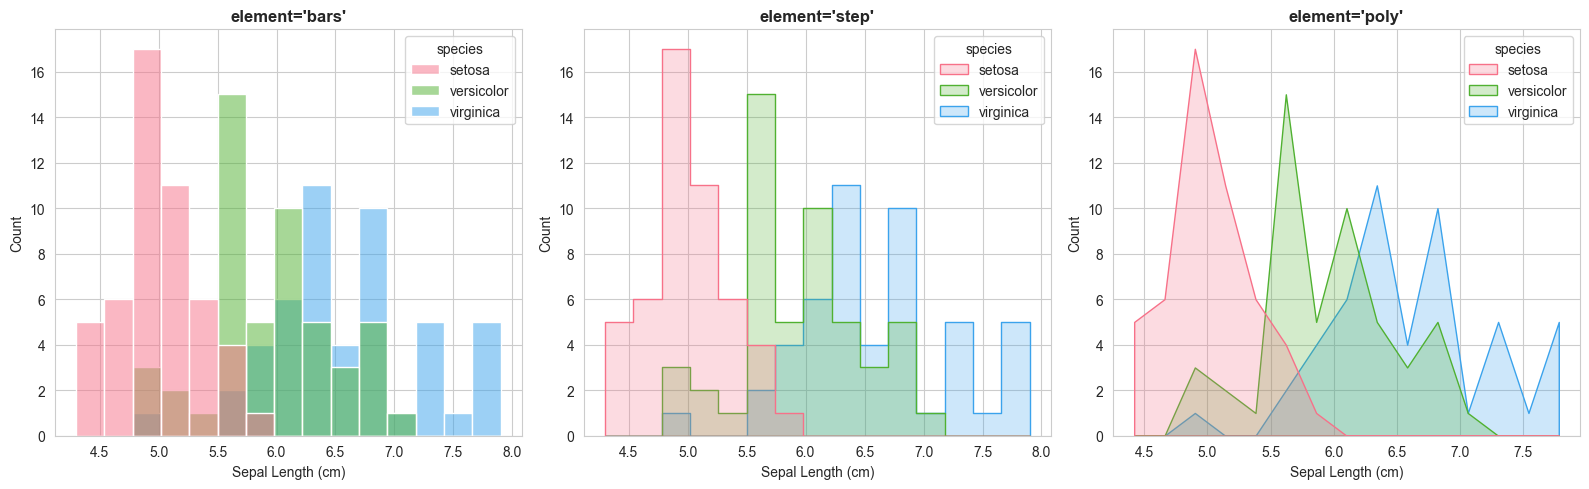

Element Types:
- 'bars' (default): Traditional stacked or grouped bars
- 'step': Step-like appearance, easier to see overlaps
- 'poly': Polygon/filled areas, useful for dense overlapping distributions


In [20]:
# Element Parameter: Different Histogram Styles
# 
# element='bars' (default) vs element='step' vs element='poly'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

elements = ['bars', 'step', 'poly']

for idx, element in enumerate(elements):
    sns.histplot(
        data=iris,
        x='sepal_length',
        hue='species',
        element=element,
        kde=False,
        bins=15,
        palette='husl',
        ax=axes[idx],
        stat='count'
    )
    axes[idx].set_title(f"element='{element}'", fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Sepal Length (cm)')
    axes[idx].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("Element Types:")
print("- 'bars' (default): Traditional stacked or grouped bars")
print("- 'step': Step-like appearance, easier to see overlaps")
print("- 'poly': Polygon/filled areas, useful for dense overlapping distributions")

In [21]:
# Load Titanic Dataset for Additional Analysis
# 
# Historical data from the RMS Titanic disaster

titanic = sns.load_dataset('titanic')

print("Titanic Dataset Overview:")
print("Shape:", titanic.shape)
print("\nColumns:", titanic.columns.tolist())
print("\nFirst few records:")
display(titanic.head(10))
print("\nMissing Values:")
print(titanic.isnull().sum())
print("\nData Types:")
print(titanic.dtypes)

Titanic Dataset Overview:
Shape: (891, 15)

Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

First few records:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False



Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Data Types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


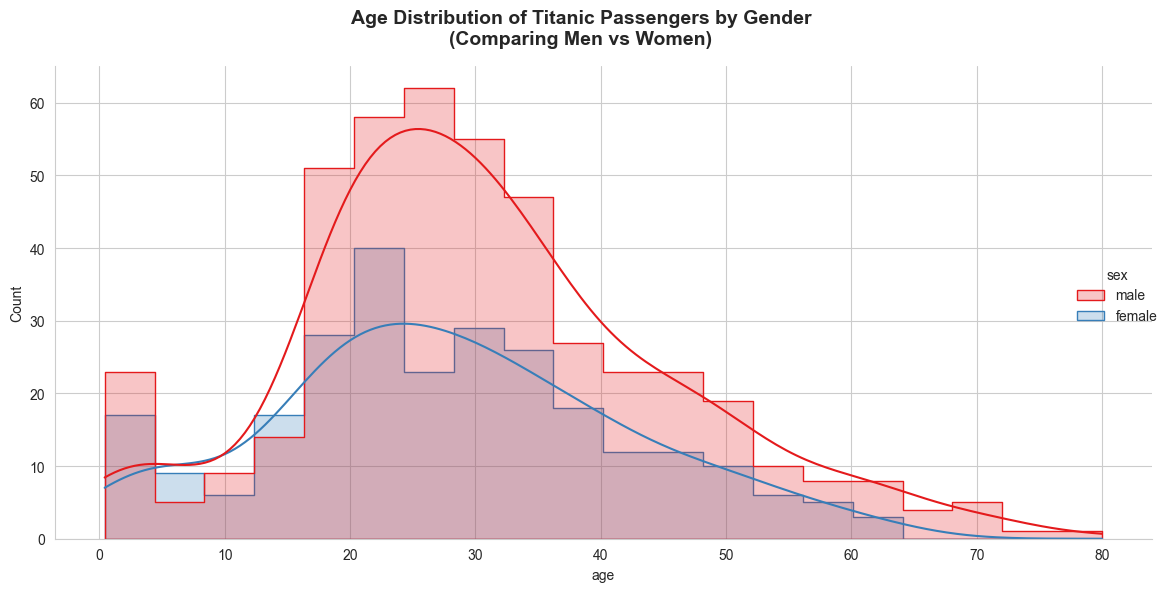

Observations:
- Female passengers: Broader age range, more children
- Male passengers: Skewed towards young to middle-aged
- This reflects the 'Women and Children First' evacuation policy


In [22]:
# Distribution Comparison: Age by Gender and Class
# 
# Remove NaN values first

titanic_clean = titanic.dropna(subset=['age', 'sex', 'pclass'])


sns.displot(
    data=titanic_clean,
    x='age',
    hue='sex',
    kind='hist',
    element='step',
    bins=20,
    kde=True,
    palette='Set1',
    height=6,
    aspect=1.8
)

plt.suptitle('Age Distribution of Titanic Passengers by Gender\n(Comparing Men vs Women)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("Observations:")
print("- Female passengers: Broader age range, more children")
print("- Male passengers: Skewed towards young to middle-aged")
print("- This reflects the 'Women and Children First' evacuation policy")

C:\Users\gaura\AppData\Local\Temp\ipykernel_24036\185537940.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.displot(


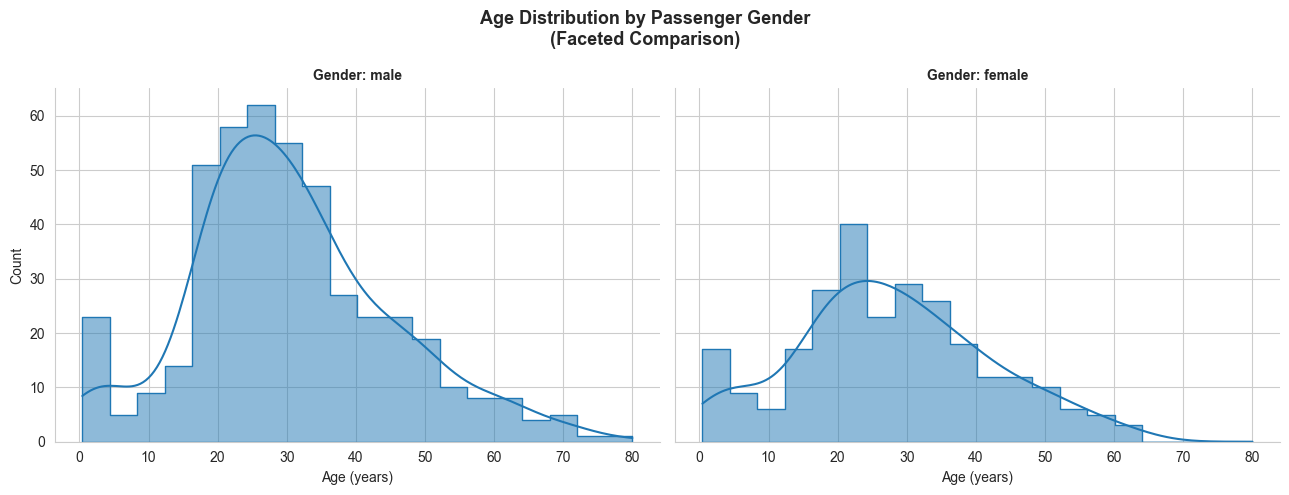

Faceting Benefits:
✓ Side-by-side comparison easier than overlapping distributions
✓ Each subplot has its own axis range (careful for comparison)
✓ Clearer view of each group's distribution characteristics


In [23]:
# Faceted Distribution: Distributions by Multiple Categories
# 
# Show age distribution separated by gender using col parameter

g = sns.displot(
    data=titanic_clean,
    x='age',
    kind='hist',
    col='sex',
    col_wrap=2,
    bins=20,
    kde=True,
    element='step',
    height=5,
    aspect=1.3,
    palette='coolwarm'
)

g.fig.suptitle('Age Distribution by Passenger Gender\n(Faceted Comparison)', 
               fontsize=13, fontweight='bold', y=0.98)
g.set_titles('Gender: {col_name}', fontweight='bold')
g.set_axis_labels('Age (years)', 'Count')

plt.tight_layout()
plt.show()

print("Faceting Benefits:")
print("✓ Side-by-side comparison easier than overlapping distributions")
print("✓ Each subplot has its own axis range (careful for comparison)")
print("✓ Clearer view of each group's distribution characteristics")

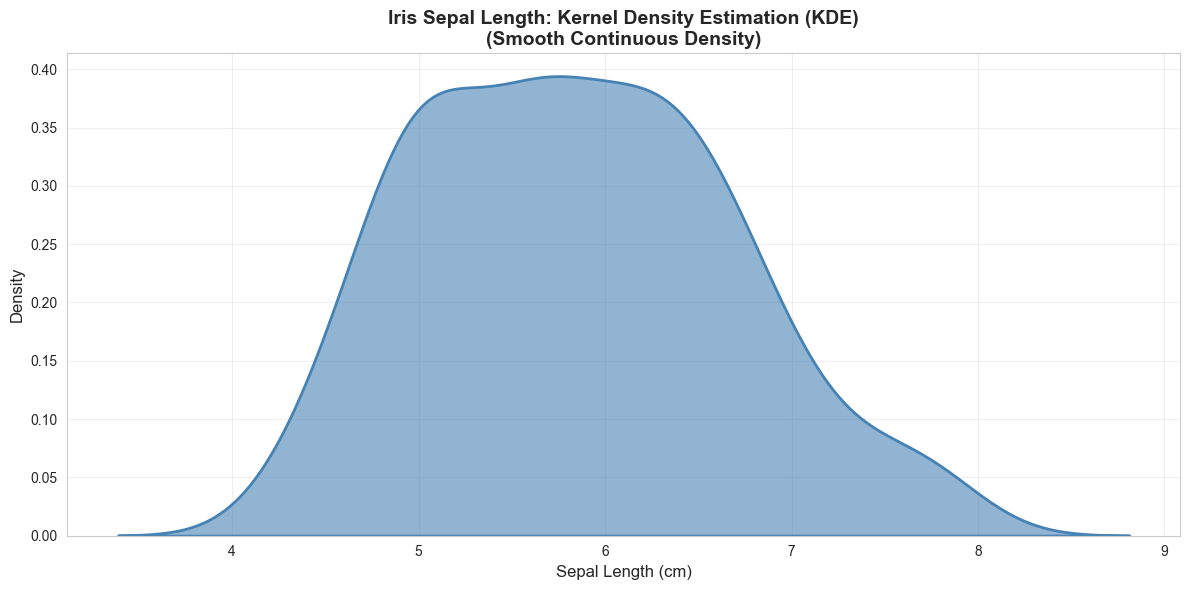

KDE vs Histogram:
Histogram:
  + Shows actual bin counts
  - Appearance depends on bin choice

KDE:
  + Smooth, continuous representation
  + No bin-edge artifacts
  - Less intuitive than counts/frequency


In [24]:
# Kernel Density Estimation (KDE) Plot
# 
# KDE smooths the data using a kernel function to create a continuous density estimate
# Much better than histogram for visualizing the overall shape

fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(
    data=iris,
    x='sepal_length',
    fill=True,
    color='steelblue',
    alpha=0.6,
    linewidth=2,
    ax=ax
)

ax.set_title('Iris Sepal Length: Kernel Density Estimation (KDE)\n(Smooth Continuous Density)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sepal Length (cm)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("KDE vs Histogram:")
print("Histogram:")
print("  + Shows actual bin counts")
print("  - Appearance depends on bin choice")
print("\nKDE:")
print("  + Smooth, continuous representation")
print("  + No bin-edge artifacts")
print("  - Less intuitive than counts/frequency")

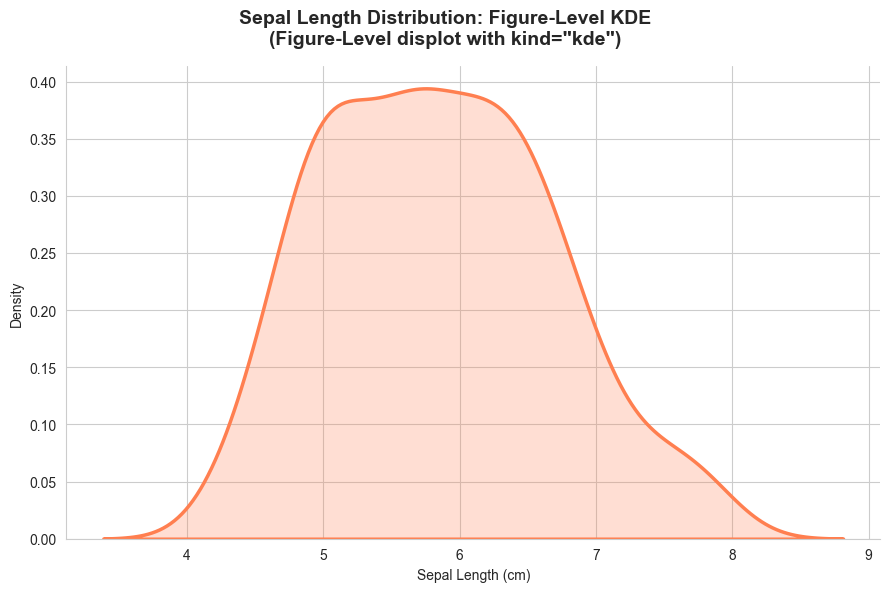

NoteAbout KDE Plots:
✓ Better for presentation and publication
✓ Shows smooth underlying distribution
✓ Useful for comparing multiple distributions


In [25]:
# Figure-Level KDE Plot: displot with kind='kde'
# 
# Using the figure-level interface for cleaner output

g = sns.displot(
    data=iris,
    x='sepal_length',
    kind='kde',
    fill=True,
    height=6,
    aspect=1.5,
    color='coral',
    linewidth=2.5
)

g.fig.suptitle('Sepal Length Distribution: Figure-Level KDE\n(Figure-Level displot with kind="kde")', 
               fontsize=14, fontweight='bold', y=0.98)
g.set_axis_labels('Sepal Length (cm)', 'Density')

plt.tight_layout()
plt.show()

print("NoteAbout KDE Plots:")
print("✓ Better for presentation and publication")
print("✓ Shows smooth underlying distribution")
print("✓ Useful for comparing multiple distributions")

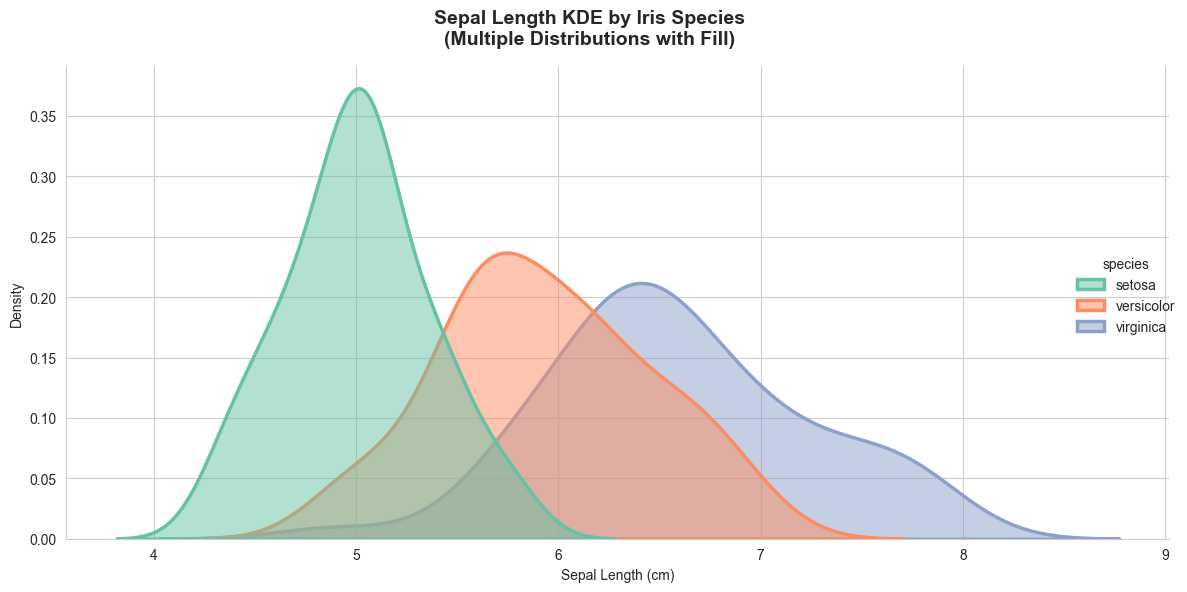

Analysis of Species Distributions:
- Setosa: Sharp peak at lower sepal lengths (≈5.0 cm)
- Versicolor: Broader distribution (6.0-7.0 cm range)
- Virginica: Peak at higher sepal lengths (≈6.5 cm)
→ Species are well-separated by sepal length!


In [26]:
# Multi-KDE with Hue and Fill
# 
# Compare distributions across categories using KDE with transparency

g = sns.displot(
    data=iris,
    x='sepal_length',
    kind='kde',
    hue='species',
    fill=True,
    height=6,
    aspect=1.8,
    palette='Set2',
    linewidth=2.5,
    alpha=0.5
)

g.fig.suptitle('Sepal Length KDE by Iris Species\n(Multiple Distributions with Fill)', 
               fontsize=14, fontweight='bold', y=0.98)
g.set_axis_labels('Sepal Length (cm)', 'Density')

plt.tight_layout()
plt.show()

print("Analysis of Species Distributions:")
print("- Setosa: Sharp peak at lower sepal lengths (≈5.0 cm)")
print("- Versicolor: Broader distribution (6.0-7.0 cm range)")
print("- Virginica: Peak at higher sepal lengths (≈6.5 cm)")
print("→ Species are well-separated by sepal length!")

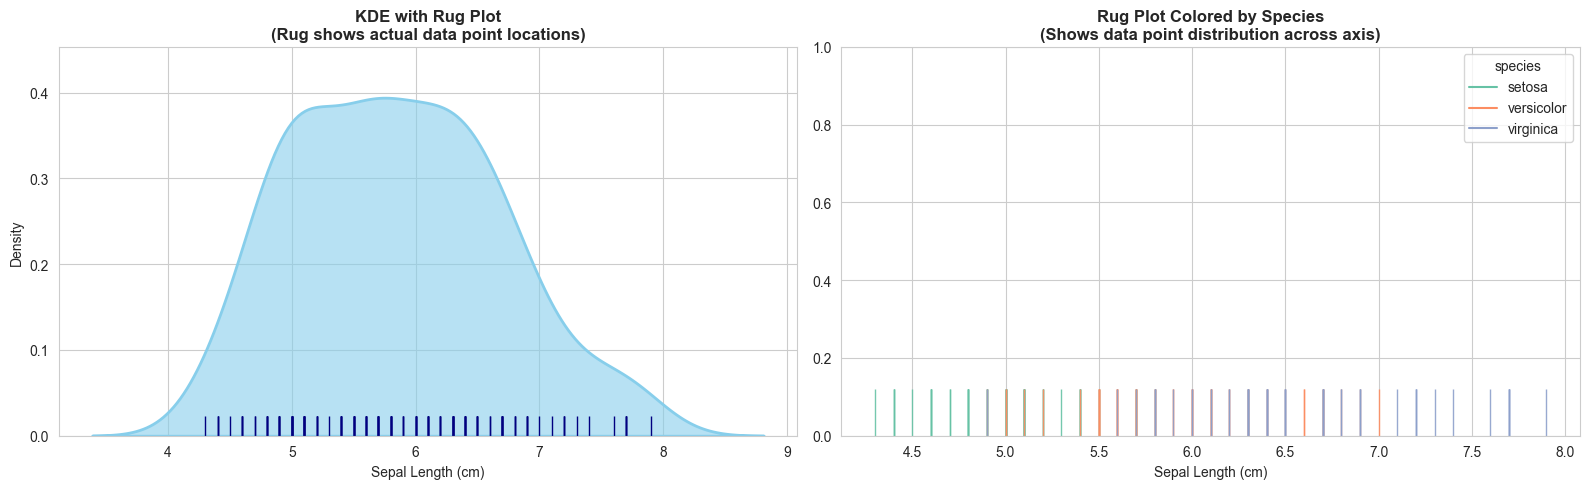

Rug Plot Characteristics:
✓ Shows exact location of each data point
✓ Reveals gaps, clusters, and outliers
✓ Works great as a complement to KDE or histogram
✓ Useful for small to medium-sized datasets


In [27]:
# Rug Plot: Individual Data Points on Axis
# 
# Plot marginal distributions by drawing ticks along the axes
# Useful for showing exact data locations without obscuring the main plot
# Best used as a complementary plot to KDE or other visualizations

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: KDE with rug plot
ax1 = axes[0]
sns.kdeplot(data=iris, x='sepal_length', fill=True, color='skyblue', linewidth=2, alpha=0.6, ax=ax1)
sns.rugplot(data=iris, x='sepal_length', height=0.05, color='navy', ax=ax1)
ax1.set_title('KDE with Rug Plot\n(Rug shows actual data point locations)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Sepal Length (cm)')
ax1.set_ylabel('Density')

# Right: Rug plot colored by species
ax2 = axes[1]

sns.rugplot(
    data=iris,
    x='sepal_length',
    hue='species',
    palette='Set2',
    height=0.12,
    alpha=0.9,
    ax=ax2
)

ax2.set_title('Rug Plot Colored by Species\n(Shows data point distribution across axis)', fontweight='bold', fontsize=12)
ax2.set_xlabel('Sepal Length (cm)')
ax2.set_ylabel('')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("Rug Plot Characteristics:")
print("✓ Shows exact location of each data point")
print("✓ Reveals gaps, clusters, and outliers")
print("✓ Works great as a complement to KDE or histogram")
print("✓ Useful for small to medium-sized datasets")

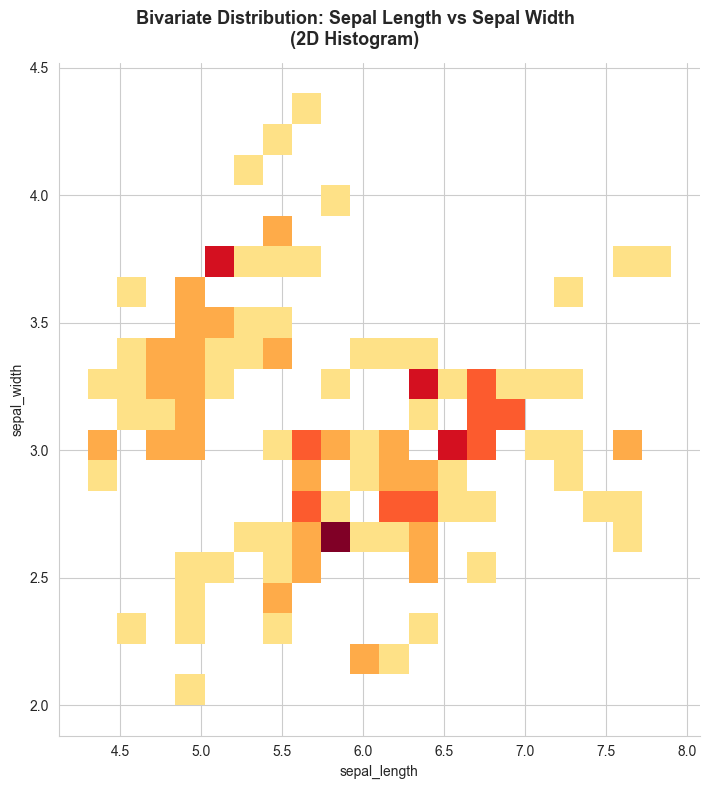

Bivariate Histogram Interpretation:
- Bins are 2D rectangles instead of 1D
- Color intensity shows frequency in each rectangle
- Reveals joint distribution patterns
- Brighter colors indicate more data points in that region


In [28]:
# Bivariate Distribution: Histogram with Two Variables
# 
# Shows joint distribution of two continuous variables
# Useful for identifying concentration areas and correlations

g = sns.displot(
    data=iris,
    x='sepal_length',
    y='sepal_width',
    kind='hist',
    cmap='YlOrRd',
    bins=20,
    height=8,
    aspect=0.9
)

g.fig.suptitle('Bivariate Distribution: Sepal Length vs Sepal Width\n(2D Histogram)', 
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("Bivariate Histogram Interpretation:")
print("- Bins are 2D rectangles instead of 1D")
print("- Color intensity shows frequency in each rectangle")
print("- Reveals joint distribution patterns")
print("- Brighter colors indicate more data points in that region")

C:\Users\gaura\AppData\Local\Temp\ipykernel_24036\1174839656.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


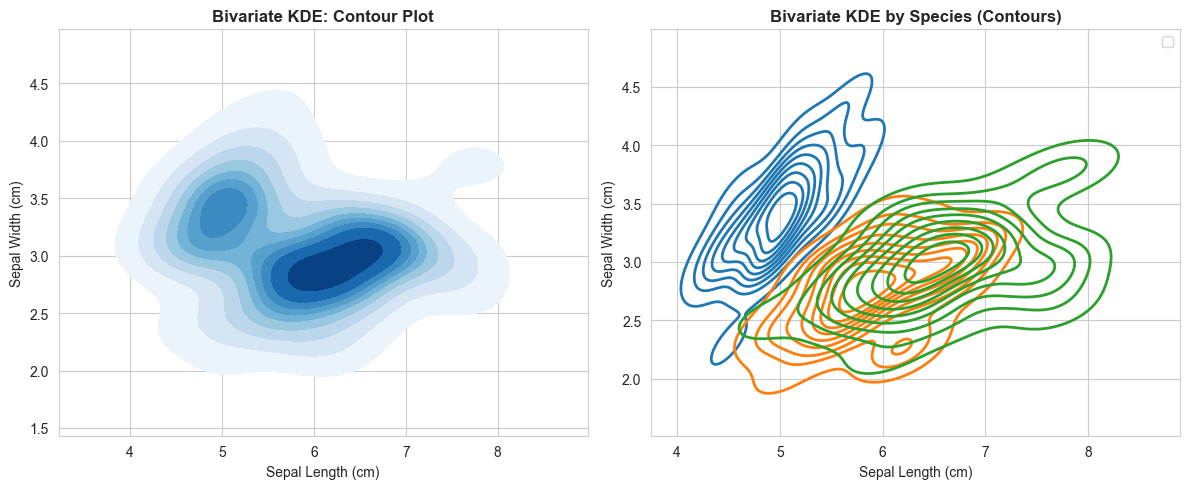

Bivariate KDE Insights:
✓ Shows relationship between two variables
✓ Contours connect points of equal density
✓ Can reveal clusters and separation between groups
✓ Better for publication than 2D histogram


In [29]:
# Bivariate KDE Plot
# 
# Smooth 2D density estimation showing joint distribution
# Uses 2D Gaussian kernel to estimate probability density

fig = plt.figure(figsize=(12, 5))

# Left: Bivariate KDE contour
ax1 = fig.add_subplot(121)
sns.kdeplot(
    data=iris,
    x='sepal_length',
    y='sepal_width',
    fill=True,
    cmap='Blues',
    thresh=0.05,
    ax=ax1
)
ax1.set_title('Bivariate KDE: Contour Plot', fontweight='bold', fontsize=12)
ax1.set_xlabel('Sepal Length (cm)')
ax1.set_ylabel('Sepal Width (cm)')

# Right: Bivariate KDE with hue
ax2 = fig.add_subplot(122)
for species in iris['species'].unique():
    subset = iris[iris['species'] == species]
    sns.kdeplot(
        data=subset,
        x='sepal_length',
        y='sepal_width',
        label=species,
        ax=ax2,
        linewidths=2
    )
ax2.set_title('Bivariate KDE by Species (Contours)', fontweight='bold', fontsize=12)
ax2.set_xlabel('Sepal Length (cm)')
ax2.set_ylabel('Sepal Width (cm)')
ax2.legend()

plt.tight_layout()
plt.show()

print("Bivariate KDE Insights:")
print("✓ Shows relationship between two variables")
print("✓ Contours connect points of equal density")
print("✓ Can reveal clusters and separation between groups")
print("✓ Better for publication than 2D histogram")

# 3. Matrix Plots

## Purpose
Matrix plots display data in a 2D grid format where:
- **Rows** represent one categorical variable
- **Columns** represent another categorical variable  
- **Color** represents the values in the matrix

Used to visualize:
- Correlation matrices
- Time series data pivoted by categories
- Multi-dimensional aggregated data
- Patterns across rows and columns

## Plot Types

### Heatmap
- Color-encoded matrix visualization
- Best for correlation matrices and aggregated data
- Each cell colored based on its value

### Clustermap
- Hierarchical clustering applied to heatmap
- Rows and columns reordered by similarity
- Better for identifying data patterns and clusters

Pivoted Data Structure:
year   1949  1950  1951  1952  1953  1954  1955  1956  1957  1958  1959  1960
month                                                                        
Jan     112   115   145   171   196   204   242   284   315   340   360   417
Feb     118   126   150   180   196   188   233   277   301   318   342   391
Mar     132   141   178   193   236   235   267   317   356   362   406   419
Apr     129   135   163   181   235   227   269   313   348   348   396   461
May     121   125   172   183   229   234   270   318   355   363   420   472

Shape: (12, 12)


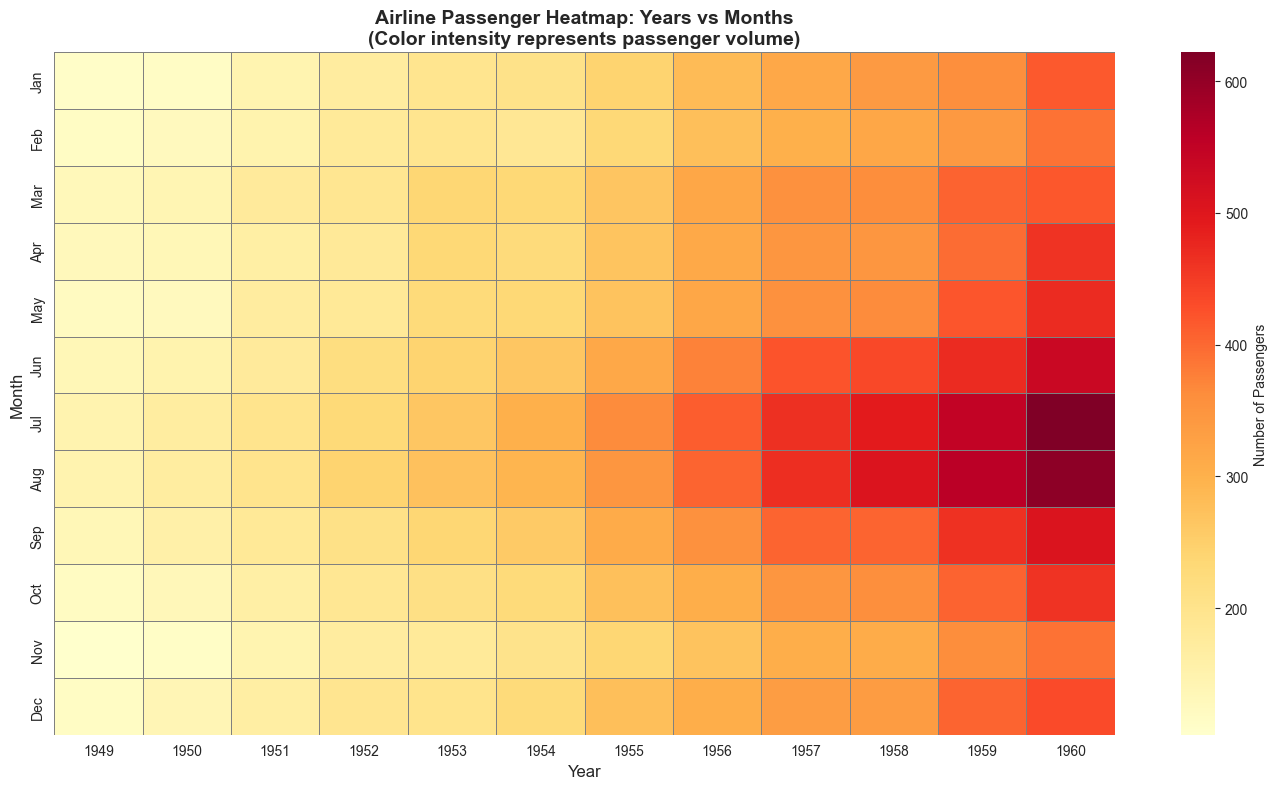


Heatmap Interpretation:
- Darker/warmer colors: More passengers
- Lighter colors: Fewer passengers
- Easy to spot seasonal patterns across years


In [30]:
# Heatmap: Visualizing Matrix Data
# 
# Pivot the flights data: rows=months, columns=years, values=passengers

# First, pivot the data
flights_pivot = flights_data.pivot(index='month', columns='year', values='passengers')

print("Pivoted Data Structure:")
print(flights_pivot.head())
print(f"\nShape: {flights_pivot.shape}")

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    flights_pivot,
    annot=False,
    cmap='YlOrRd',
    cbar_kws={'label': 'Number of Passengers'},
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)

ax.set_title('Airline Passenger Heatmap: Years vs Months\n(Color intensity represents passenger volume)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Month', fontsize=12)

plt.tight_layout()
plt.show()

print("\nHeatmap Interpretation:")
print("- Darker/warmer colors: More passengers")
print("- Lighter colors: Fewer passengers")
print("- Easy to spot seasonal patterns across years")

Iris Features Correlation Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


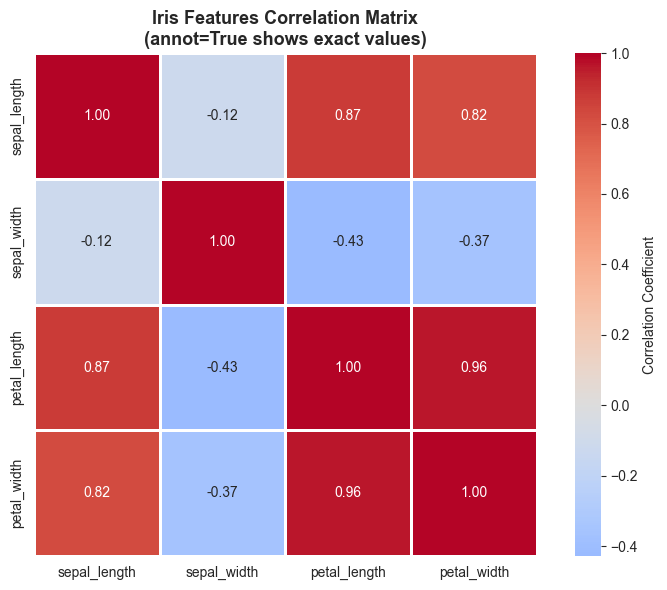


Key Correlations:
- Strong positive: Sepal length ↔ Petal length, width
- Moderate: Sepal width ↔ Petal measurements
- Red colors: Positive correlation, Blue: Negative


In [31]:
# Annotation Heatmap: Showing Exact Values
# 
# Create a correlation matrix from iris data and display with annotations

# Calculate correlation matrix
correlation_matrix = iris.iloc[:, :-1].corr()  # Exclude 'species' column

print("Iris Features Correlation Matrix:")
print(correlation_matrix.round(3))

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,              # Show values in cells
    fmt='.2f',               # Format with 2 decimal places
    cmap='coolwarm',         # Cool-warm diverging palette
    center=0,                # Center colormap at 0
    square=True,             # Square cells
    linewidths=1,
    cbar_kws={'label': 'Correlation Coefficient'},
    ax=ax
)

ax.set_title('Iris Features Correlation Matrix\n(annot=True shows exact values)', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey Correlations:")
print("- Strong positive: Sepal length ↔ Petal length, width")
print("- Moderate: Sepal width ↔ Petal measurements")
print("- Red colors: Positive correlation, Blue: Negative")

## Heatmap Customization Parameters

- **annot**: Display values in cells (True/False)
- **fmt**: Format string for annotations ('.2f' for 2 decimals, 'd' for integers)
- **cmap**: Colormap palette ('viridis', 'coolwarm', 'RdYlGn', 'YlOrRd', etc.)
- **center**: Value where colormap is centered (useful for diverging colormaps)
- **linewidths**: Width of lines between cells
- **square**: Make cells square-shaped (True/False)
- **cbar**: Show color bar (True/False)

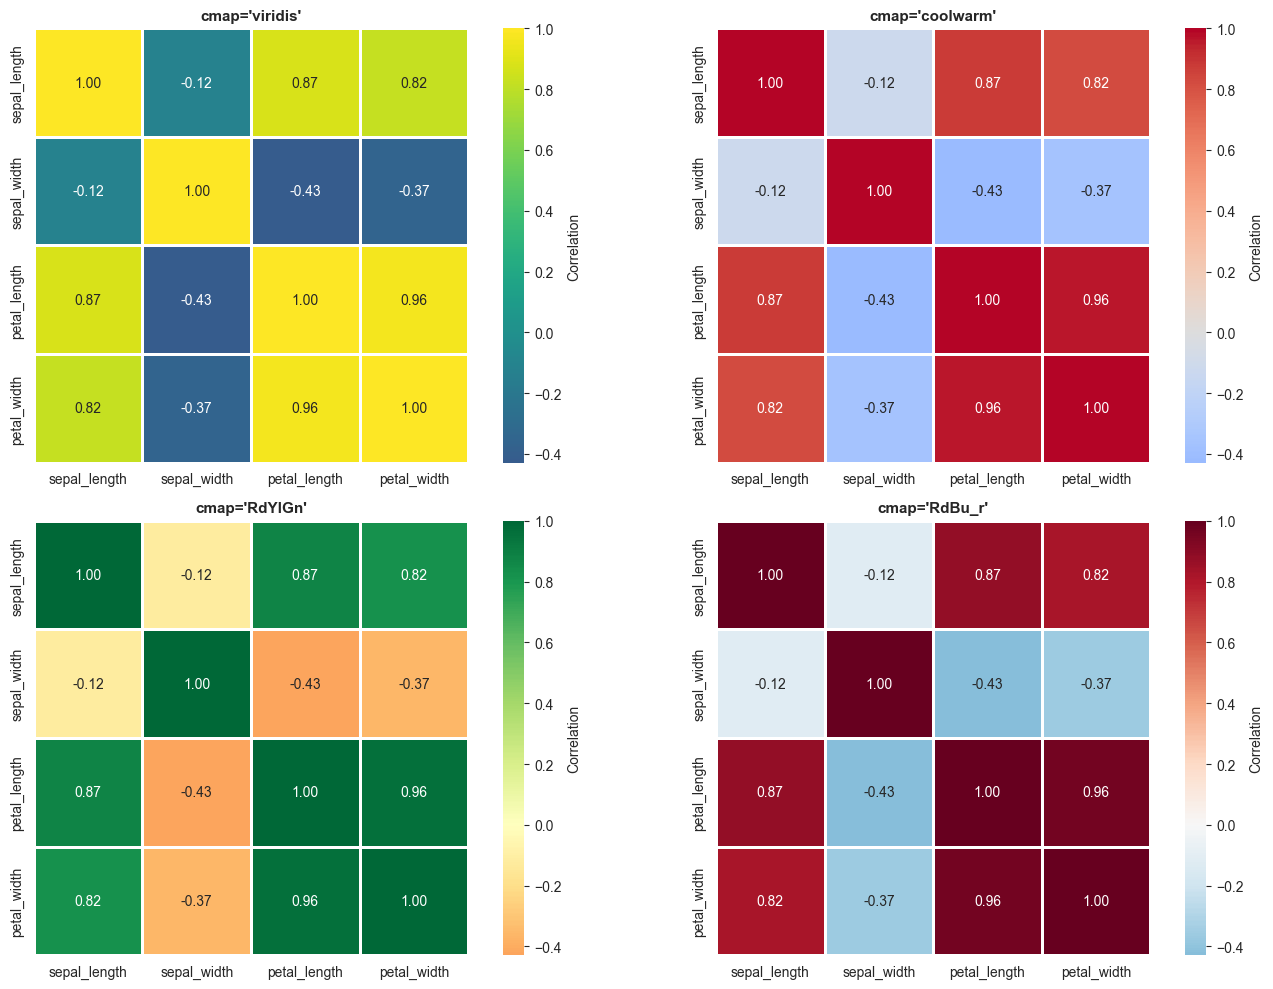

Colormap Selection Tips:
- 'viridis': Sequential, colorblind-friendly
- 'coolwarm': Diverging, blue-red, good for centered data
- 'RdYlGn': Diverging, red-yellow-green, intuitive for good-bad data
- '_r': Add '_r' suffix to reverse any colormap


In [32]:
# Comparing Different Colormaps
# 
# Different colormaps emphasize different aspects of the data

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cmaps = ['viridis', 'coolwarm', 'RdYlGn', 'RdBu_r']
correlation_data = iris.iloc[:, :-1].corr()

for idx, (ax, cmap) in enumerate(zip(axes.flat, cmaps)):
    sns.heatmap(
        correlation_data,
        annot=True,
        fmt='.2f',
        cmap=cmap,
        center=0,
        square=True,
        linewidths=1,
        cbar_kws={'label': 'Correlation'},
        ax=ax
    )
    ax.set_title(f"cmap='{cmap}'", fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("Colormap Selection Tips:")
print("- 'viridis': Sequential, colorblind-friendly")
print("- 'coolwarm': Diverging, blue-red, good for centered data")
print("- 'RdYlGn': Diverging, red-yellow-green, intuitive for good-bad data")
print("- '_r': Add '_r' suffix to reverse any colormap")

In [33]:
# Clustermap: Hierarchical Clustering on Heatmap
# 
# Clustermap performs unsupervised clustering on rows and columns
# This requires scipy library

print("Dataset for Clustering:")
print("\nIris Features (numeric columns only):")

# Use only numeric features
iris_numeric = iris.iloc[:, :-1]
print(iris_numeric.head())
print(f"\nShape: {iris_numeric.shape}")

# Standardize the data for better clustering
from sklearn.preprocessing import StandardScaler

iris_scaled = StandardScaler().fit_transform(iris_numeric)
iris_scaled_df = pd.DataFrame(
    iris_scaled,
    columns=iris_numeric.columns
)

print("\nScaled Data (first 5 rows):")
display(iris_scaled_df.head())

Dataset for Clustering:

Iris Features (numeric columns only):
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Shape: (150, 4)



Scaled Data (first 5 rows):


,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


# Summary: When to Use Each Plot Type

## Relational Plots
**Use when:** Exploring relationships between continuous variables
- **Scatter plot**: Find correlations, clusters, outliers (2+ dimensions)
- **Line plot**: Show trends and time series data

## Distribution Plots
**Use when:** Understanding a single variable's distribution
- **Histogram**: See frequency distribution and bin structure
- **KDE Plot**: Smooth density estimation for presentations
- **Rug Plot**: Show exact data point locations, identify gaps

## Matrix Plots
**Use when:** Visualizing relationships in tabular/matrix data
- **Heatmap**: Display correlations, aggregated categorical data
- **Clustermap**: Find patterns through hierarchical clustering

## Best Practices
1. **Always explore your data** with multiple plot types
2. **Use figure-level functions** (relplot, displot) for publication-ready plots
3. **Add hue/color coding** to encode additional dimensions
4. **Facet your data** (col/row) when comparing groups
5. **Choose appropriate colormaps** considering colorblind viewers
6. **Annotate key findings** to guide viewer interpretation
7. **Use seaborn's built-in themes** for consistent, professional looks

## Resources
- Seaborn Documentation: https://seaborn.pydata.org/
- Gallery Examples: https://seaborn.pydata.org/examples/index.html
- Matplotlib Colormaps: https://matplotlib.org/stable/tutorials/colors/colormaps.html